MNIST IMAGE CLASSIFICATION USING RNN

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN ,Dense, Dropout, Bidirectional
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [3]:
print(x_train.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)


In [4]:
x_train = x_train / 255.0 # To normalize the pixel values, we divide by 255 (the maximum pixel value for grayscale images).
x_test = x_test / 255.0
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [5]:

num_classes = 10 # Number of classes in the MNIST dataset (digits 0-9)
y_train = to_categorical(y_train, num_classes) #1 hotencoding the labels
y_test = to_categorical(y_test, num_classes)

In [11]:
model = Sequential()
model.add(Bidirectional(SimpleRNN(units=64, return_sequences=False), input_shape=(x_train.shape[1], x_train.shape[2])))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

In [12]:
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional_2 (Bidirecti  (None, 128)               11904     
 onal)                                                           
                                                                 
 dense_4 (Dense)             (None, 64)                8256      
                                                                 
 dense_5 (Dense)             (None, 10)                650       
                                                                 
Total params: 20810 (81.29 KB)
Trainable params: 20810 (81.29 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [13]:
#train model
history = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_data=(x_test, y_test))

Epoch 1/5


938/938 [==============================] - 8s 7ms/step - loss: 0.3657 - accuracy: 0.8885 - val_loss: 0.1842 - val_accuracy: 0.9428
Epoch 2/5
938/938 [==============================] - 6s 6ms/step - loss: 0.1553 - accuracy: 0.9526 - val_loss: 0.1376 - val_accuracy: 0.9576
Epoch 3/5
938/938 [==============================] - 6s 6ms/step - loss: 0.1222 - accuracy: 0.9622 - val_loss: 0.1128 - val_accuracy: 0.9658
Epoch 4/5
938/938 [==============================] - 6s 6ms/step - loss: 0.1058 - accuracy: 0.9677 - val_loss: 0.1051 - val_accuracy: 0.9675
Epoch 5/5
938/938 [==============================] - 6s 6ms/step - loss: 0.0920 - accuracy: 0.9714 - val_loss: 0.0887 - val_accuracy: 0.9716


In [14]:
test_loss,test_acc = model.evaluate(x_test,y_test,verbose=2)
print(f'Test Accuracy:{test_acc}')

313/313 - 1s - loss: 0.0887 - accuracy: 0.9716 - 708ms/epoch - 2ms/step
Test Accuracy:0.9715999960899353


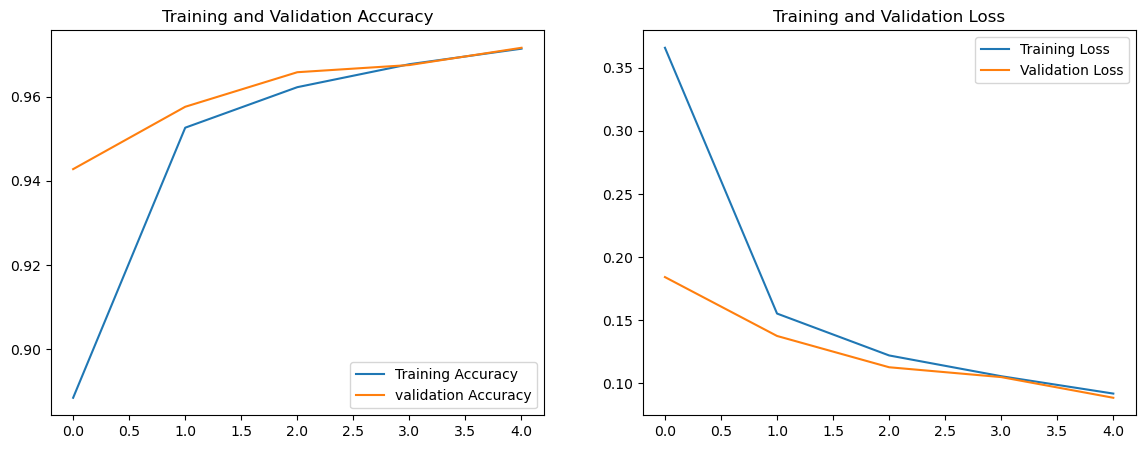

In [15]:
#plot Training and validation accuracy and loss
import matplotlib.pyplot as plt
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='validation Accuracy')
plt.legend(loc='lower right')
plt.title("Training and Validation Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.savefig('./RNNM_NIST.png')
plt.show()
